# 4. Correlation and diversification

**Question:** does combining assets reduce risk, and by how much?

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from investor_toolkit import diversification as dv
from investor_toolkit import proxies, universe
from investor_toolkit.plotting import plot_correlation, plot_frontier, plot_lines

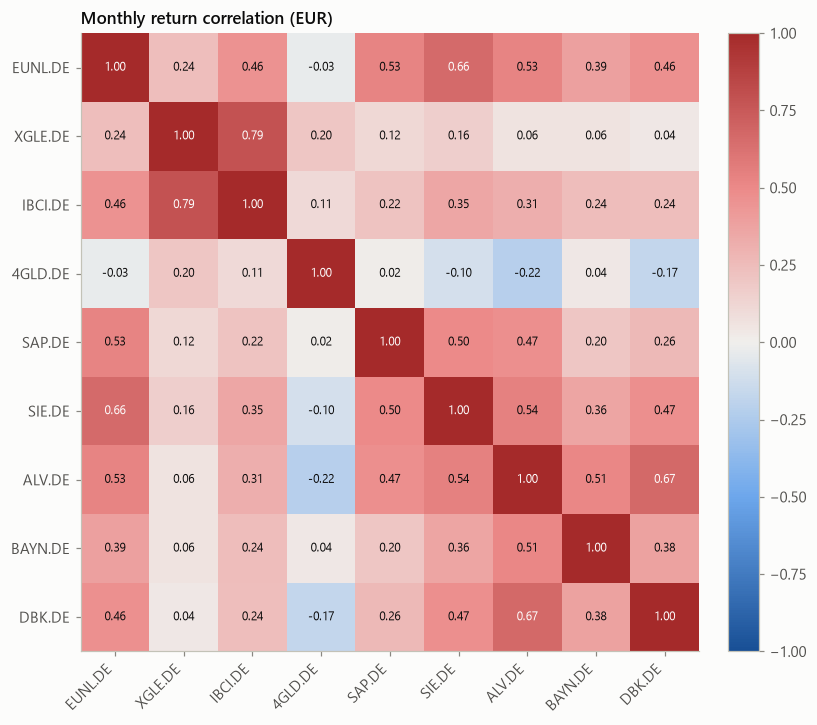

In [2]:
returns = universe.load_asset_returns()
long = proxies.long_history()
ax = plot_correlation(returns.corr(), title="Monthly return correlation (EUR)")
ax.figure.savefig(f"{FIGURES}/correlation.png")

## How much does adding assets help?

For $N$ equally weighted assets with common volatility $\sigma$ and pairwise correlation $\rho$:

$$\sigma_p^2 = \sigma^2\left(\rho + \frac{1 - \rho}{N}\right)$$

As $N$ grows, the second term vanishes but the first does not: only the uncorrelated part of risk
can be diversified away. The five stocks of the concentrated portfolio illustrate this.

In [3]:
stocks = returns[universe.MODEL_PORTFOLIOS["concentrated"].tickers]
cov = stocks.cov().to_numpy()
avg_vol = np.sqrt(np.diag(cov)).mean()
corr = stocks.corr().to_numpy()
avg_rho = corr[np.triu_indices(len(corr), 1)].mean()
n = np.arange(1, 31)
theory = np.sqrt(dv.equal_weight_variance(avg_vol, avg_rho, n) * 12)

pd.Series(
    {
        "average single-stock volatility": avg_vol * np.sqrt(12),
        "average pairwise correlation": avg_rho,
        "formula, N = 5": theory[4],
        "actual equal-weight portfolio": dv.portfolio_volatility(np.full(5, 0.2), cov)
        * np.sqrt(12),
        "floor, N -> infinity": np.sqrt(avg_rho) * avg_vol * np.sqrt(12),
        "MSCI World ETF": returns["EUNL.DE"].std() * np.sqrt(12),
    }
)

average single-stock volatility    0.265
average pairwise correlation       0.436
formula, N = 5                     0.196
actual equal-weight portfolio      0.195
floor, N -> infinity               0.175
MSCI World ETF                     0.124
dtype: float64

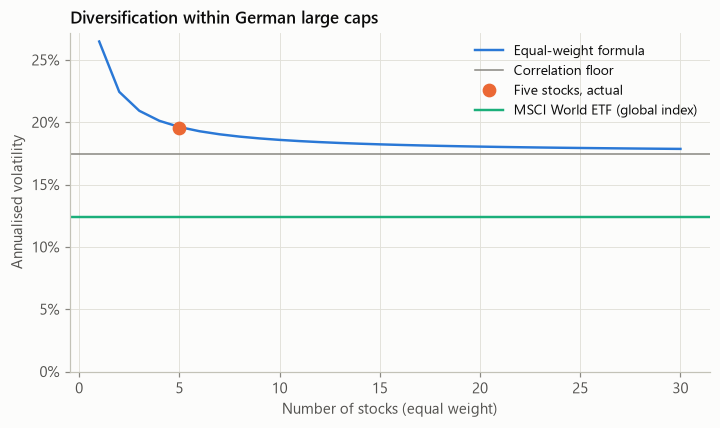

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(n, theory, color="#2a78d6", label="Equal-weight formula")
ax.axhline(
    np.sqrt(avg_rho) * avg_vol * np.sqrt(12),
    color="#898781",
    linewidth=1.0,
    label="Correlation floor",
)
ax.plot(
    5,
    dv.portfolio_volatility(np.full(5, 0.2), cov) * np.sqrt(12),
    "o",
    color="#eb6834",
    markersize=8,
    label="Five stocks, actual",
)
ax.axhline(
    returns["EUNL.DE"].std() * np.sqrt(12),
    color="#1baf7a",
    linewidth=1.6,
    label="MSCI World ETF (global index)",
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Number of stocks (equal weight)")
ax.set_ylabel("Annualised volatility")
ax.set_ylim(bottom=0)
ax.set_title("Diversification within German large caps")
ax.legend()
fig.savefig(f"{FIGURES}/diversification_curve.png")

The formula, using only the average volatility and correlation, predicts the actual five-stock
portfolio almost exactly. Adding more stocks *of the same kind* would barely help, because the
floor is set by their high mutual correlation. The global index lies far below that floor: real
diversification comes from adding assets that are less correlated, not just more assets.

## Is the stock-bond hedge stable?

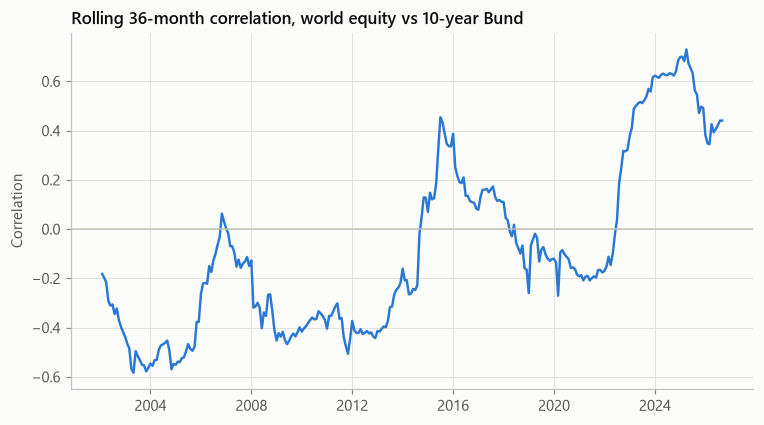

In [5]:
rolling = dv.rolling_correlation(long["world_equity"], long["bund_10y"], 36).dropna()
ax = plot_lines(
    rolling.to_frame("World equity vs 10y Bund"),
    title="Rolling 36-month correlation, world equity vs 10-year Bund",
)
ax.axhline(0, color="#c3c2b7", linewidth=1.0)
ax.set_ylabel("Correlation")
ax.figure.savefig(f"{FIGURES}/stock_bond_correlation.png")

For most of the period since 2000, government bonds were negatively correlated with equities,
which made them an excellent hedge. Since the 2022 inflation shock the correlation has turned
clearly positive. A balanced portfolio's risk depends on which regime holds, and a covariance
matrix estimated over the full sample hides this.

## Do correlations rise in crises?

Conditioning on bad market months changes measured correlation *even when the true correlation is
constant*. For a bivariate normal pair, correlation conditional on the market lying below its
$q$-quantile is

$$\rho_A = \frac{\rho}{\sqrt{\rho^2 + (1 - \rho^2)/v_A}}$$

where $v_A$ is the variance of the truncated market return (Boyer, Gibson and Loretan, 1997). Since
$v_A < 1$, conditioning *lowers* correlation. Only differences from this benchmark are evidence of
a genuine crisis effect.

In [6]:
pd.concat(
    {
        "ETF era": dv.downside_correlations(
            returns[["EUNL.DE", "XGLE.DE", "IBCI.DE", "4GLD.DE"]], "EUNL.DE", quantile=0.2
        ),
        "long history": dv.downside_correlations(
            long[["world_equity", "bund_10y"]], "world_equity", quantile=0.2
        ),
    },
    names=["sample", "asset"],
)

full_sample  down_market  normal_benchmark  n_down  excess
sample       asset                                                               
ETF era      XGLE.DE         0.236        0.019             0.113      41  -0.094
             IBCI.DE         0.456        0.366             0.233      41   0.133
             4GLD.DE        -0.030       -0.133            -0.014      41  -0.119
long history bund_10y       -0.055       -0.152            -0.026      67  -0.126

Gold and government bonds were *less* correlated with equities in the worst 20% of equity months
than the constant-correlation benchmark predicts: they hedged when it mattered. Inflation-linked
bonds behaved more like risk assets in sell-offs. The down-market samples are small, so these
differences are indicative rather than conclusive.

## Portfolio construction

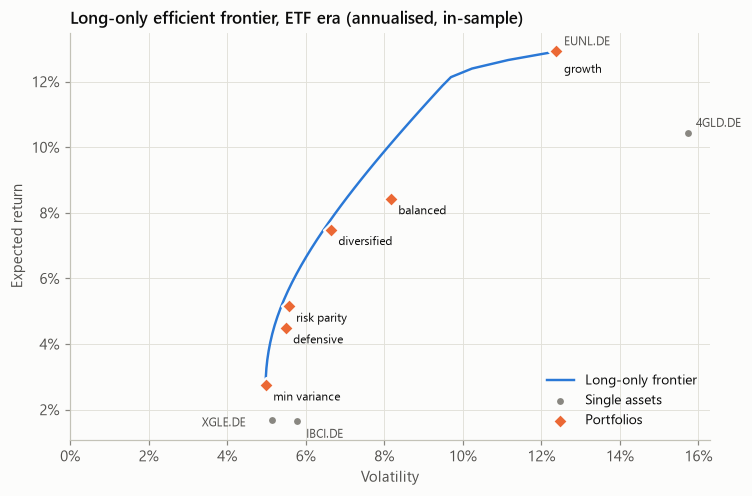

In [7]:
assets = ["EUNL.DE", "XGLE.DE", "IBCI.DE", "4GLD.DE"]
mu = returns[assets].mean().to_numpy() * 12
cov_annual = returns[assets].cov().to_numpy() * 12
frontier = dv.efficient_frontier(mu, cov_annual, n_points=40, asset_names=assets)
asset_points = pd.DataFrame({"mean": mu, "volatility": np.sqrt(np.diag(cov_annual))}, index=assets)

portfolios = {}
for name in ["defensive", "balanced", "growth", "diversified"]:
    w = universe.MODEL_PORTFOLIOS[name].weight_vector(assets).to_numpy()
    portfolios[name] = {"mean": w @ mu, "volatility": dv.portfolio_volatility(w, cov_annual)}
for name, w in [
    ("min variance", dv.min_variance_weights(cov_annual)),
    ("risk parity", dv.risk_parity_weights(cov_annual)),
]:
    portfolios[name] = {"mean": w @ mu, "volatility": dv.portfolio_volatility(w, cov_annual)}
ax = plot_frontier(
    frontier,
    asset_points,
    pd.DataFrame(portfolios).T,
    title="Long-only efficient frontier, ETF era (annualised, in-sample)",
    label_offsets={"XGLE.DE": (-46, -4), "IBCI.DE": (6, -11), "growth": (5, -14)},
)
ax.figure.savefig(f"{FIGURES}/frontier.png")

The frontier uses historical means, which are estimated with large error; it is an in-sample
description, not a forecast. Risk-based portfolios (minimum variance, risk parity) do not need
expected returns at all, which makes them more robust out of sample (tested in notebook 6).

**Risk contributions** show where a portfolio's risk actually comes from:

In [8]:
rows = {}
for name in ["defensive", "balanced", "diversified"]:
    w = universe.MODEL_PORTFOLIOS[name].weight_vector(assets).to_numpy()
    rows[(name, "weight")] = w
    rows[(name, "risk share")] = dv.risk_contributions(w, cov_annual)
for name, w in [
    ("risk parity", dv.risk_parity_weights(cov_annual)),
    ("min variance", dv.min_variance_weights(cov_annual)),
]:
    rows[(name, "weight")] = w
    rows[(name, "risk share")] = dv.risk_contributions(w, cov_annual)
table = pd.DataFrame(rows, index=assets).T
table["diversification ratio"] = [
    dv.diversification_ratio(table.loc[(n, "weight"), assets].to_numpy(), cov_annual)
    for n, _ in table.index
]
table

EUNL.DE  XGLE.DE  IBCI.DE  4GLD.DE  diversification ratio
defensive    weight        0.250    0.750    0.000    0.000                  1.267
             risk share    0.412    0.588    0.000    0.000                  1.267
balanced     weight        0.600    0.400    0.000    0.000                  1.162
             risk share    0.882    0.118    0.000    0.000                  1.162
diversified  weight        0.400    0.300    0.150    0.150                  1.465
             risk share    0.634    0.135    0.090    0.140                  1.465
risk parity  weight        0.183    0.356    0.299    0.162                  1.506
             risk share    0.250    0.250    0.250    0.250                  1.506
min variance weight        0.058    0.740    0.154    0.048                  1.238
             risk share    0.058    0.740    0.154    0.048                  1.238

A 60/40 portfolio is "balanced" in capital but not in risk: equities contribute the large
majority of its volatility. Risk parity equalises the contributions and achieves the highest
diversification ratio.

**Takeaways**

* Diversification is limited by correlation, not by the number of holdings.
* The equity-bond correlation is regime dependent and turned positive after 2022.
* After accounting for the conditioning bias, bonds and gold hedged equity sell-offs in this sample.
* Capital weights hide risk concentration; risk contributions reveal it.